In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df = pd.read_csv('student_mental_health_burnout.csv',low_memory=True)

In [4]:
df.head()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


In [5]:
df.shape

(1000000, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

In [7]:
df.isnull().sum()

age                     0
gender                  0
academic_year           0
study_hours_per_day     0
exam_pressure           0
academic_performance    0
stress_level            0
anxiety_score           0
depression_score        0
sleep_hours             0
physical_activity       0
social_support          0
screen_time             0
internet_usage          0
financial_stress        0
family_expectation      0
burnout_score           0
mental_health_index     0
risk_level              0
dropout_risk            0
dtype: int64

In [8]:
df = df.drop_duplicates()

In [9]:
# Creating a smaller random sample of 10,000 rows for quick testing and visualization
sample_df = df.sample(10000, random_state=42)

# Creating a training subset of 200,000 rows from the dataset for model training
train_df = df.sample(200000, random_state=42)

In [10]:
def burnout_category(score):
    if score < 5:
        return 0   # Low
    elif score < 7:
        return 1   # Moderate
    else:
        return 2   # High

In [11]:
train_df['burnout_category'] = train_df['burnout_score'].apply(
    burnout_category
)

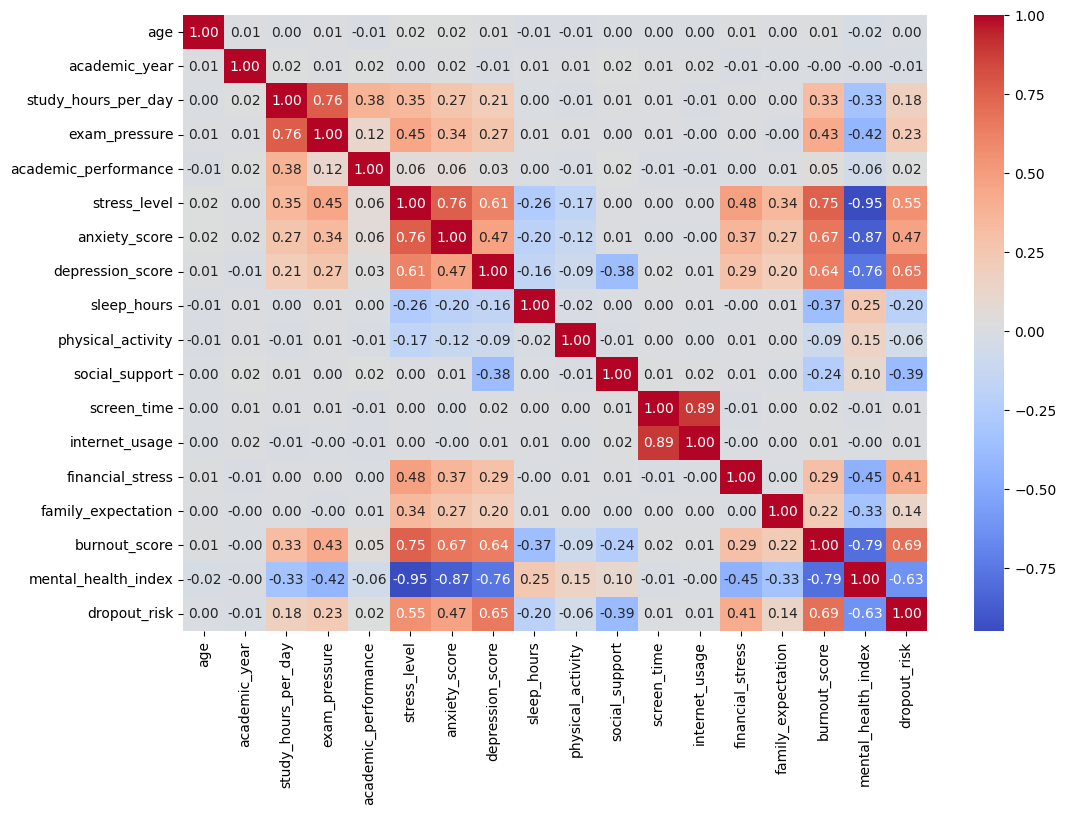

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(
    sample_df.select_dtypes(include=np.number).corr(),annot=True,fmt='.2f',
    cmap='coolwarm'
)

plt.show()

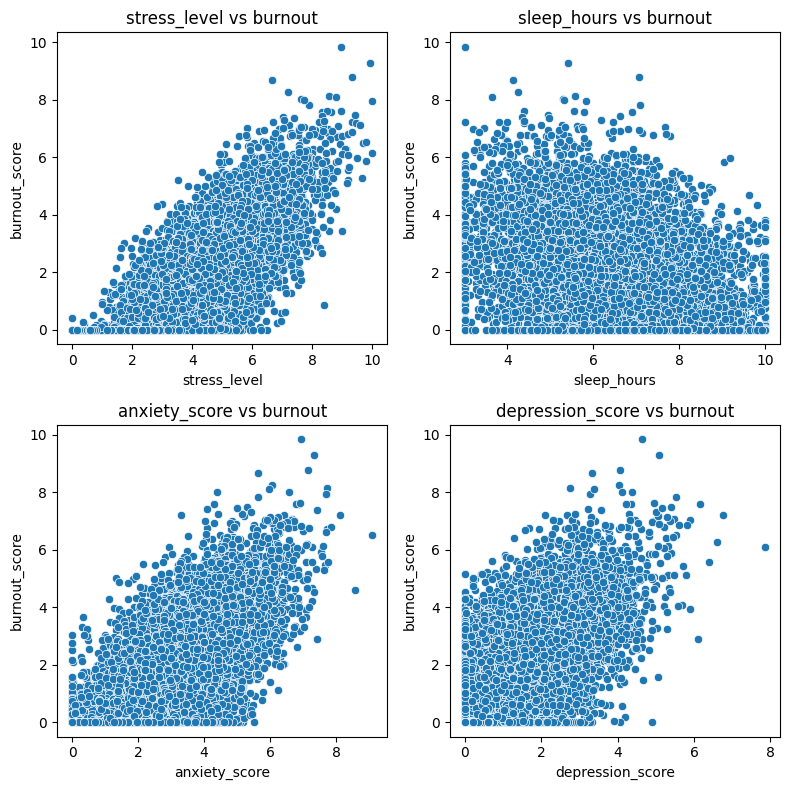

In [13]:
important_features = ['stress_level','sleep_hours','anxiety_score','depression_score']
plt.figure(figsize=(8,8))

for i, col in enumerate(important_features):
    plt.subplot(2,2,i+1)
    sns.scatterplot(
        x=sample_df[col],
        y=sample_df['burnout_score']
    )
    plt.title(f'{col} vs burnout')

plt.tight_layout()
plt.show()

In [14]:
features = [
    'study_hours_per_day',
    'exam_pressure',
    'stress_level',
    'anxiety_score',
    'depression_score',
    'sleep_hours',
    'physical_activity',
    'social_support',
    'financial_stress',
    'family_expectation'
]

In [15]:
#dividing the data into X and y

X = train_df[features]
y = train_df['burnout_category']

In [16]:
#train test split 

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [17]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, lr_preds))

Logistic Regression
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     38153
           1       0.60      0.37      0.46      1689
           2       0.66      0.22      0.33       158

    accuracy                           0.96     40000
   macro avg       0.74      0.53      0.59     40000
weighted avg       0.96      0.96      0.96     40000



In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced', random_state=42)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, rf_preds))

Random Forest
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     38153
           1       0.25      0.81      0.38      1689
           2       0.33      0.51      0.40       158

    accuracy                           0.89     40000
   macro avg       0.52      0.74      0.57     40000
weighted avg       0.96      0.89      0.91     40000



In [19]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(random_state=42)

hgb_model.fit(X_train, y_train)
hgb_preds = hgb_model.predict(X_test)

print("HistGradientBoosting")
print(classification_report(y_test, hgb_preds))

HistGradientBoosting
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     38153
           1       0.57      0.30      0.39      1689
           2       0.33      0.24      0.28       158

    accuracy                           0.96     40000
   macro avg       0.62      0.51      0.55     40000
weighted avg       0.95      0.96      0.95     40000



Accuracy is misleading here.
Because: Low burnout dominates dataset
So: even weak models can get high accuracy 

recall for minority classes matters more

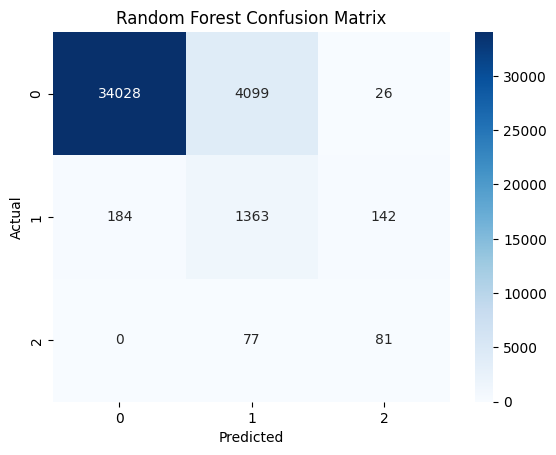

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [21]:
joblib.dump(rf_model, 'burnout_model.pkl')

['burnout_model.pkl']

In [22]:
def predict_burnout(data):

    prediction = rf_model.predict([data])[0]

    if prediction == 0:
        return "Low Burnout"

    elif prediction == 1:
        return "Moderate Burnout"

    else:
        return "High Burnout"

In [23]:
student = [
    6,
    8,
    7,
    6,
    5,
    4,
    2,
    3,
    7,
    8
]

print(predict_burnout(student))

High Burnout


In [24]:
student = [
    2,
    2,
    2,
    1,
    1,
    8,
    8,
    8,
    1,
    2
]
print(predict_burnout(student))

Low Burnout


In [25]:
student = [
    5,
    5,
    5,
    4,
    4,
    6,
    5,
    5,
    5,
    5
]
print(predict_burnout(student))

Low Burnout
